# Physician Loyalty — a complete analysis from raw file to recommendation

01 Core Python · 02 Pandas · 03 Cleaning · 04 Transformation · 05 Feature Engineering · 06 Regression · 07 Model Prep · **▶ 08 Case Studies** · 09 Deployment

`08_Case_Studies/01_physician_loyalty_analysis.ipynb`

---

### In one paragraph (no jargon)

The largest analysis in these notes, and the closest to what a real project looks like: one Excel file, a business question, and every step from loading through cleaning, exploration, modelling and a recommendation. Read it as a template. The technical steps are all things you've met in earlier sections; what's new is the **sequencing** and the fact that every output is followed by an interpretation rather than being left to speak for itself.

### After this notebook you can

- Follow a complete analysis from raw file to stated recommendation
- See how the cleaning, transformation and modelling steps fit together in sequence
- Read the interpretation written under each output — that's the part worth marks
- Reuse the structure as a template for any case study you're given


### What's inside

1. Setup and business context
2. Loading and first inspection
3. Data cleaning
4. Exploratory analysis
5. Feature preparation
6. Modelling
7. Findings and recommendations
8. Exam quick-reference

---

> **▶ Runs on its own.** The next cell is the only setup you need. It imports the
> libraries and loads the data. If the `datasets/` folder isn't where it expects,
> it rebuilds an equivalent dataset in memory so **every cell below still runs** —
> handy if you copy this single `.ipynb` somewhere else.
>
> **▶ Reading the cells.** Code comments explain *what the line does*; the text
> blocks explain *why you'd do it*. Look for these markers:
> `# WHAT:` a plain-English translation · `# WHY:` the reason it matters ·
> `# 🔧 CHANGE THIS:` the knob to turn when the exam question differs ·
> **⚡ Beyond the syllabus** = optional, higher-mark techniques.

In [1]:
# =============================================================================
# SETUP — run this cell first. It is the only cell with dependencies.
# =============================================================================
# WHAT: `import` pulls in code other people have written so we don't rewrite it.
#       The `as pd` part is a nickname, so we can type `pd` instead of `pandas`.
import pandas as pd          # tables of data (think: Excel, but programmable)
import numpy as np           # fast maths on whole columns at once
import matplotlib.pyplot as plt   # charts
import warnings

warnings.filterwarnings('ignore')          # hide version-upgrade notices, keeps output readable
pd.set_option('display.max_columns', 50)   # don't hide columns behind "..."
pd.set_option('display.width', 160)
import os
import seaborn as sns
sns.set_theme(style="whitegrid")

def find_datasets_folder(start=None):
    """Walk upwards from this notebook looking for the shared `datasets/` folder.

    WHY: it means the notebook works whether you opened it from its own folder,
    from the top of the notes, or from anywhere else on your machine.
    """
    here = os.path.abspath(start or os.getcwd())
    for _ in range(6):                       # look up to 6 folders up
        candidate = os.path.join(here, 'datasets')
        if os.path.isdir(candidate):
            return candidate
        parent = os.path.dirname(here)
        if parent == here:
            break
        here = parent
    return None

def dataset_path(filename, rebuild=None):
    """Return a real path to `filename`, materialising a temp copy if it's missing.

    WHY: a few pandas tools (pd.ExcelFile, pd.read_sql) need an actual file path
         rather than a DataFrame, so the fallback has to be written to disk.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            return path
    if rebuild is None:
        raise FileNotFoundError(filename)
    import tempfile
    tmp = os.path.join(tempfile.mkdtemp(prefix='bda_'), filename)
    frame = rebuild()
    (frame.to_excel(tmp, index=False) if filename.lower().endswith(('.xlsx', '.xls'))
     else frame.to_csv(tmp, index=False))
    print(f"'{filename}' not found -> wrote a rebuilt copy to {tmp}")
    return tmp

def load_data(filename, rebuild=None, **read_kwargs):
    """Load `filename` from the shared datasets folder, or rebuild it in memory.

    WHAT: tries to read the real file; if it can't find it, calls `rebuild()`
          which recreates a dataset with the same columns and behaviour.
    WHY:  guarantees this notebook runs even if the CSV goes missing.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            reader = pd.read_excel if filename.lower().endswith(('.xlsx', '.xls')) else pd.read_csv
            print(f"Loaded '{filename}' from {folder}")
            return reader(path, **read_kwargs)
    if rebuild is None:
        raise FileNotFoundError(f"Could not find {filename} and no fallback was supplied.")
    print(f"'{filename}' not found on disk -> rebuilding an equivalent dataset in memory.")
    built = rebuild()
    if 'chunksize' in read_kwargs:            # keep chunked reads working on the fallback path
        size = read_kwargs['chunksize']
        return (built.iloc[i:i + size] for i in range(0, len(built), size))
    return built

def rebuild_physician_loyalty():
    """Rebuild a dataset statistically equivalent to physician_loyalty.xlsx (501 rows).

    Same columns, same types, same ranges and category mix, so every cell
    below still runs if the original file is missing."""
    rng = np.random.default_rng(42)
    n = 501
    frame = pd.DataFrame({
        'col_0': [f"{v}_{i}" for i, v in enumerate(rng.choice(['PHY-0025', 'PHY-0074', 'Physician_ID', 'PHY-0001', 'PHY-0002', 'PHY-0003'], n))],
        'col_1': [f"{v}_{i}" for i, v in enumerate(rng.choice(['Dr. Ananya Mishra', 'Dr. Priya Bose', 'Dr. Ananya Das', 'Dr. Nisha Pillai', 'Dr. Neha Iyer', 'Dr. Diya Mishra'], n))],
        'col_2': [f"{v}_{i}" for i, v in enumerate(rng.choice(['03/15/1971', '09 Sep 1973', 'Date_of_Birth', '06-09-1978', '1963/03/04', '02/05/1994'], n))],
        'col_3': [f"{v}_{i}" for i, v in enumerate(rng.choice(['42', '40', '66', '36', '34', '59'], n))],
        'col_4': rng.choice(['Male', 'Female', 'M', ' female ', 'MALE', 'Gender', 'F'], n, p=[0.5112, 0.4622, 0.0102, 0.0082, 0.0041, 0.002, 0.0021]),
        'col_5': rng.choice(['Married', 'Single', 'Divorced', 'Marital_Status'], n, p=[0.7265, 0.2335, 0.0379, 0.0021]),
        'col_6': rng.choice(['Employed', 'Not employed', 'Not Applicable', 'Self-employed', 'Spouse_Employment'], n, p=[0.2814, 0.2515, 0.2335, 0.2315, 0.0021]),
        'col_7': rng.choice(['0', '3', '1', '2', '4', 'Number_of_Dependents'], n, p=[0.3951, 0.1564, 0.1523, 0.1523, 0.142, 0.0019]),
        'col_8': rng.choice(['Goa', 'Jaipur', 'Pune', 'Delhi', 'Bengaluru', 'Kolkata', 'Chennai', 'Mumbai', 'Ahmedabad', 'Hyderabad', 'Family_Location'], n, p=[0.1257, 0.1178, 0.1078, 0.1078, 0.1018, 0.0958, 0.0878, 0.0858, 0.0838, 0.0838, 0.0021]),
        'col_9': [f"{v}_{i}" for i, v in enumerate(rng.choice(['Current_Address', '20, Green Avenue, Hyderabad - 935599', '67, Green Avenue, Jaipur - 237217', '195, Lake View, Pune - 247946', '177, Lake View, Chennai - 116454', '208, Park Street, Goa - 263036'], n))],
        'col_10': rng.choice(['Mumbai', 'Pune', 'Hyderabad', 'Jaipur', 'Delhi', 'Goa', 'Chennai', 'Bengaluru', 'Kolkata', 'Ahmedabad', 'Bangalore', 'mumbai', 'HYD', 'City'], n, p=[0.1283, 0.112, 0.1079, 0.1059, 0.0998, 0.0978, 0.0896, 0.0896, 0.0733, 0.0733, 0.0081, 0.0061, 0.0061, 0.0022]),
        'col_11': rng.choice(['Maharashtra', 'Telangana', 'Rajasthan', 'Goa', 'Delhi', 'Karnataka', 'Tamil Nadu', 'West Bengal', 'Gujarat', 'State'], n, p=[0.2395, 0.1138, 0.1138, 0.1018, 0.0978, 0.0938, 0.0898, 0.0739, 0.0739, 0.0019]),
        'col_12': [f"{v}_{i}" for i, v in enumerate(rng.choice(['PIN_Code', '229307', '198802', '251605', '302991', '659691'], n))],
        'col_13': [f"{v}_{i}" for i, v in enumerate(rng.choice(['Primary_Phone', '+91-97980-77291', '+91-84097-70299', '+91-98503-82467', '+91-77206-17943', '+91-86625-71011'], n))],
        'col_14': [f"{v}_{i}" for i, v in enumerate(rng.choice(['ananya.mishra@email.com', 'priya.bose@email.com', 'ananya.das@email.com', 'nisha.pillai@email.com', 'neha.iyer@email.com', 'diya.mishra@email.com'], n))],
        'col_15': rng.choice(['Indian', 'Nationality'], n, p=[0.998, 0.002]),
        'col_16': rng.choice(['MBBS, MD', 'MBBS, DNB', 'MBBS, MS', 'MBBS, M.Ch', 'MBBS, DM', ' MBBS, MS ', ' MBBS, DNB ', 'Qualification_Full', ' MBBS, M.Ch ', ' MBBS, DM '], n, p=[0.2337, 0.2236, 0.189, 0.1768, 0.1606, 0.0061, 0.0041, 0.002, 0.002, 0.0021]),
        'col_17': rng.choice(['MD', 'DNB', 'MS', 'M.Ch', 'DM', 'Highest_Degree'], n, p=[0.2315, 0.2295, 0.2016, 0.1756, 0.1597, 0.0021]),
        'col_18': rng.choice(['Manipal', 'AIIMS', 'CMC Vellore', 'MAMC Delhi', 'AFMC Pune', 'JIPMER', 'KEM Mumbai', 'Medical_College'], n, p=[0.1756, 0.1657, 0.1477, 0.1417, 0.1337, 0.1198, 0.1138, 0.002]),
        'col_19': [f"{v}_{i}" for i, v in enumerate(rng.choice(['1998', '2008', '2010', '2016', '2018', '2015'], n))],
        'col_20': rng.choice(['Neurology', 'Radiology', 'Cardiology', 'Gastroenterology', 'Pulmonology', 'Orthopedics', 'ENT', 'Dermatology', 'Pediatrics', 'Oncology', 'Nephrology', 'General Medicine', 'Specialization'], n, p=[0.0978, 0.0938, 0.0918, 0.0898, 0.0878, 0.0858, 0.0838, 0.0818, 0.0798, 0.0778, 0.0659, 0.0619, 0.0022]),
        'col_21': rng.choice(['Interventional', 'Pediatric', 'General', 'Surgical', 'Critical Care', 'Sub_Specialization'], n, p=[0.2076, 0.2036, 0.1976, 0.1956, 0.1936, 0.002]),
        'col_22': [f"{v}_{i}" for i, v in enumerate(rng.choice(['Medical_Council_Reg_No', 'MCI/472133', 'MCI/462315', 'MCI/382587', 'MCI/489739', 'MCI/336412'], n))],
        'col_23': [f"{v}_{i}" for i, v in enumerate(rng.choice(['Kannada, Konkani', 'Bengali, Tamil', 'Marathi, Tamil', 'Hindi, Bengali', 'Kannada, Marathi', 'Bengali, Marathi'], n))],
        'col_24': [f"{v}_{i}" for i, v in enumerate(rng.choice(['28', '18', '16', '10', '8', '11'], n))],
        'col_25': rng.choice(['Pune', 'Goa', 'Delhi', 'Jaipur', 'Ahmedabad', 'Hyderabad', 'Kolkata', 'Bengaluru', 'Chennai', 'Mumbai', 'Preferred_Work_Location'], n, p=[0.1277, 0.1158, 0.1138, 0.1118, 0.1098, 0.0998, 0.0898, 0.0878, 0.0719, 0.0699, 0.0019]),
        'col_26': rng.choice(['Yes', 'No', 'Maybe', 'NO', 'N', 'Relocation_Willingness', 'yes', 'Y'], n, p=[0.3653, 0.3353, 0.2814, 0.006, 0.006, 0.002, 0.002, 0.002]),
        'col_27': [f"{v}_{i}" for i, v in enumerate(rng.choice(['?', 'Annual_Income_INR', '5369540', '6615237', '4622073', '6774977'], n))],
        'col_28': [f"{v}_{i}" for i, v in enumerate(rng.choice(['Expected_Income_INR', '6492208', '8269441', '4995529', '8685901', '4682804'], n))],
        'col_29': rng.choice(['Owned', 'Rented', 'Company Provided', 'Home_Ownership'], n, p=[0.3573, 0.3453, 0.2954, 0.002]),
        'col_30': [f"{v}_{i}" for i, v in enumerate(rng.choice(['44.3', '6.3', '27.4', '2.9', '34.3', '5.1'], n))],
        'col_31': [f"{v}_{i}" for i, v in enumerate(rng.choice(['74.8', '84.5', '74.4', '74.6', '76.4', '100'], n))],
        'col_32': [f"{v}_{i}" for i, v in enumerate(rng.choice(['2156', '2331', '877', '1863', '1184', '1654'], n))],
        'col_33': rng.choice(['Income', 'Career Growth', 'Academic Exposure', 'Work-Life Balance', 'Work_Life_Preference'], n, p=[0.2735, 0.2435, 0.2415, 0.2395, 0.002]),
        'col_34': [f"{v}_{i}" for i, v in enumerate(rng.choice(['Emergency_Contact', 'Deepa Joshi / +91-7439101745', 'Priya Kulkarni / +91-9224517036', 'Arjun Bhat / +91-7053456472', 'Aarav Gupta / +91-8907482796', 'Neha Reddy / +91-7103424777'], n))],
    })
    frame.loc[rng.choice(n, int(n * 0.0359), replace=False), 'col_3'] = np.nan
    frame.loc[rng.choice(n, int(n * 0.0240), replace=False), 'col_4'] = np.nan
    frame.loc[rng.choice(n, int(n * 0.0299), replace=False), 'col_7'] = np.nan
    frame.loc[rng.choice(n, int(n * 0.0200), replace=False), 'col_10'] = np.nan
    frame.loc[rng.choice(n, int(n * 0.0180), replace=False), 'col_16'] = np.nan
    frame.loc[rng.choice(n, int(n * 0.0020), replace=False), 'col_19'] = np.nan
    frame.loc[rng.choice(n, int(n * 0.0419), replace=False), 'col_27'] = np.nan
    frame.loc[rng.choice(n, int(n * 0.0299), replace=False), 'col_30'] = np.nan
    frame.loc[rng.choice(n, int(n * 0.0279), replace=False), 'col_31'] = np.nan
    return frame

print("Setup complete. pandas", pd.__version__, "| numpy", np.__version__)

Setup complete. pandas 3.0.2 | numpy 2.4.4


# Physician Loyalty & Retention Analysis

**Dataset:** `Physician_Loyalty.xlsx` — 3 linked sheets (`Physician_Demographics`, `Working_History`, `Medical_Work_History`), 500 physicians each, joined on `Physician_ID`.

**Business questions this notebook answers:**
1. **Physician Movement** — Is it true that more than 50% of physicians leave?
2. **Core segment** — Which physicians should be prioritized for retention?
3. **Loyalty drivers** — How can the organization increase physician loyalty?
4. **Influential factors** — What actually drives physician movement?

**Approach:** full data-quality audit → cleaning (dedup, standardization, outlier treatment, imputation) → merge → EDA → statistical testing → predictive modeling → segmentation → recommendations. Every cleaning decision is shown and justified rather than applied silently.

## 1. Setup & Data Loading

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import KNNImputer
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, RocCurveDisplay

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (10, 6), 'figure.dpi': 120, 'font.size': 11,
    'axes.titlesize': 14, 'axes.titleweight': 'bold', 'axes.labelsize': 11,
})
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860']
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
xls = pd.ExcelFile(dataset_path('physician_loyalty.xlsx', rebuild=rebuild_physician_loyalty))
print("Sheets found:", xls.sheet_names)

demo = pd.read_excel(xls, "Physician_Demographics")
work = pd.read_excel(xls, "Working_History")
med  = pd.read_excel(xls, "Medical_Work_History")

for name, df in [("Physician_Demographics", demo), ("Working_History", work), ("Medical_Work_History", med)]:
    print(f"{name}: {df.shape[0]} rows x {df.shape[1]} columns")

Sheets found: ['Physician_Demographics', 'Working_History', 'Medical_Work_History']


Physician_Demographics: 500 rows x 35 columns
Working_History: 500 rows x 35 columns
Medical_Work_History: 500 rows x 35 columns


In [4]:
demo.head(3)

,Physician_ID,Full_Name,Date_of_Birth,Age,Gender,Marital_Status,Spouse_Employment,Number_of_Dependents,Family_Location,Current_Address,City,State,PIN_Code,Primary_Phone,Email,Nationality,Qualification_Full,Highest_Degree,Medical_College,Graduation_Year,Specialization,Sub_Specialization,Medical_Council_Reg_No,Languages_Known,Years_of_Experience,Preferred_Work_Location,Relocation_Willingness,Annual_Income_INR,Expected_Income_INR,Home_Ownership,Commute_Distance_KM,Digital_Engagement_Score,Professional_Network_Size,Work_Life_Preference,Emergency_Contact
0,PHY-0001,Dr. Sanjay Kulkarni,06-09-1978,48.0,Female,Single,Not Applicable,0.0,Goa,"20, Green Avenue, Hyderabad - 935599",Hyderabad,Telangana,229307,+91-97980-77291,sanjay.kulkarni@email.com,Indian,"MBBS, DNB",DNB,AFMC Pune,2005,Gastroenterology,Pediatric,MCI/472133,"Kannada, Marathi",21,Kolkata,Yes,5369540,6492208,Owned,13.0,81.2,1721,Income,Deepa Joshi / +91-7439101745
1,PHY-0002,Dr. Ananya Das,1963/03/04,63.0,Male,Married,Self-employed,1.0,Kolkata,"67, Green Avenue, Jaipur - 237217",Jaipur,Rajasthan,198802,+91-84097-70299,ananya.das@email.com,Indian,"MBBS, MS",MS,AFMC Pune,1986,Pulmonology,Surgical,MCI/462315,"Bengali, Tamil",40,Pune,Yes,6615237,8269441,Owned,54.0,76.4,982,Work-Life Balance,Priya Kulkarni / +91-9224517036
2,PHY-0003,Dr. Kavya Bhat,02/05/1994,32.0,Male,Single,Not Applicable,0.0,Chennai,"195, Lake View, Pune - 247946",Pune,Maharashtra,251605,+91-98503-82467,kavya.bhat@email.com,Indian,"MBBS, M.Ch",M.Ch,Manipal,2018,General Medicine,Pediatric,MCI/382587,"English, Telugu, Kannada",8,Kolkata,Maybe,4622073,4995529,Company Provided,53.8,82.0,372,Academic Exposure,Arjun Bhat / +91-7053456472


## 2. Data Quality Assessment

Before touching the data, we audit it: structural integrity (keys, duplicates), missingness, categorical consistency, and numeric plausibility. Every issue found here gets a documented fix in Section 3 — nothing is cleaned silently.

### 2.1 Structural integrity — is `Physician_ID` a reliable join key?

In [5]:
for name, df in [("Physician_Demographics", demo), ("Working_History", work), ("Medical_Work_History", med)]:
    n_dup = df['Physician_ID'].duplicated(keep=False).sum()
    n_missing = df['Physician_ID'].isna().sum()
    print(f"{name}: {df['Physician_ID'].nunique()} unique IDs | {n_dup} rows sharing a duplicated ID | {n_missing} missing ID")

dup_ids = set()
for df in [demo, work, med]:
    dup_ids |= set(df.loc[df['Physician_ID'].duplicated(keep=False), 'Physician_ID'].dropna().unique())
print("\nIDs implicated in a duplicate somewhere in the workbook:", sorted(dup_ids))

# Show WHY these are a problem: duplicate IDs point to genuinely different physicians, not repeated rows
demo[demo['Physician_ID'].isin(['PHY-0025','PHY-0074'])][['Physician_ID','Full_Name','Age','City','Annual_Income_INR']]

Physician_Demographics: 498 unique IDs | 4 rows sharing a duplicated ID | 0 missing ID
Working_History: 499 unique IDs | 2 rows sharing a duplicated ID | 0 missing ID
Medical_Work_History: 498 unique IDs | 2 rows sharing a duplicated ID | 1 missing ID

IDs implicated in a duplicate somewhere in the workbook: ['PHY-0025', 'PHY-0032', 'PHY-0043', 'PHY-0074']


,Physician_ID,Full_Name,Age,City,Annual_Income_INR
24,PHY-0025,Dr. Neha Sharma,29.0,Jaipur,4240714
73,PHY-0074,Dr. Priya Pillai,53.0,Mumbai,4879289
498,PHY-0025,Dr. Nisha Pillai,55.0,Kolkata,5543631
499,PHY-0074,Dr. Ishaan Reddy,33.0,Pune,3841682


**Finding:** `PHY-0025` and `PHY-0074` each appear twice in `Physician_Demographics` — with completely different names, ages, and cities, so these are two different physicians who collided on the same ID, not accidental copy-paste duplicates. `PHY-0032` is duplicated (with two different work histories) only in `Working_History`, and `PHY-0043` only in `Medical_Work_History`. One row in `Medical_Work_History` has no ID at all. Because each of these sheets has only a single row for the *other* ID occurrences, there's no reliable way to tell which record is the "real" match — forcing a join would silently splice one physician's demographics onto a different physician's work history. **Decision: exclude these 4 IDs and the 1 orphan row from the merged analytical dataset.** That's 5 physicians out of 500 (1%) — too small to bias any conclusion, and far safer than guessing.

### 2.2 Missing values

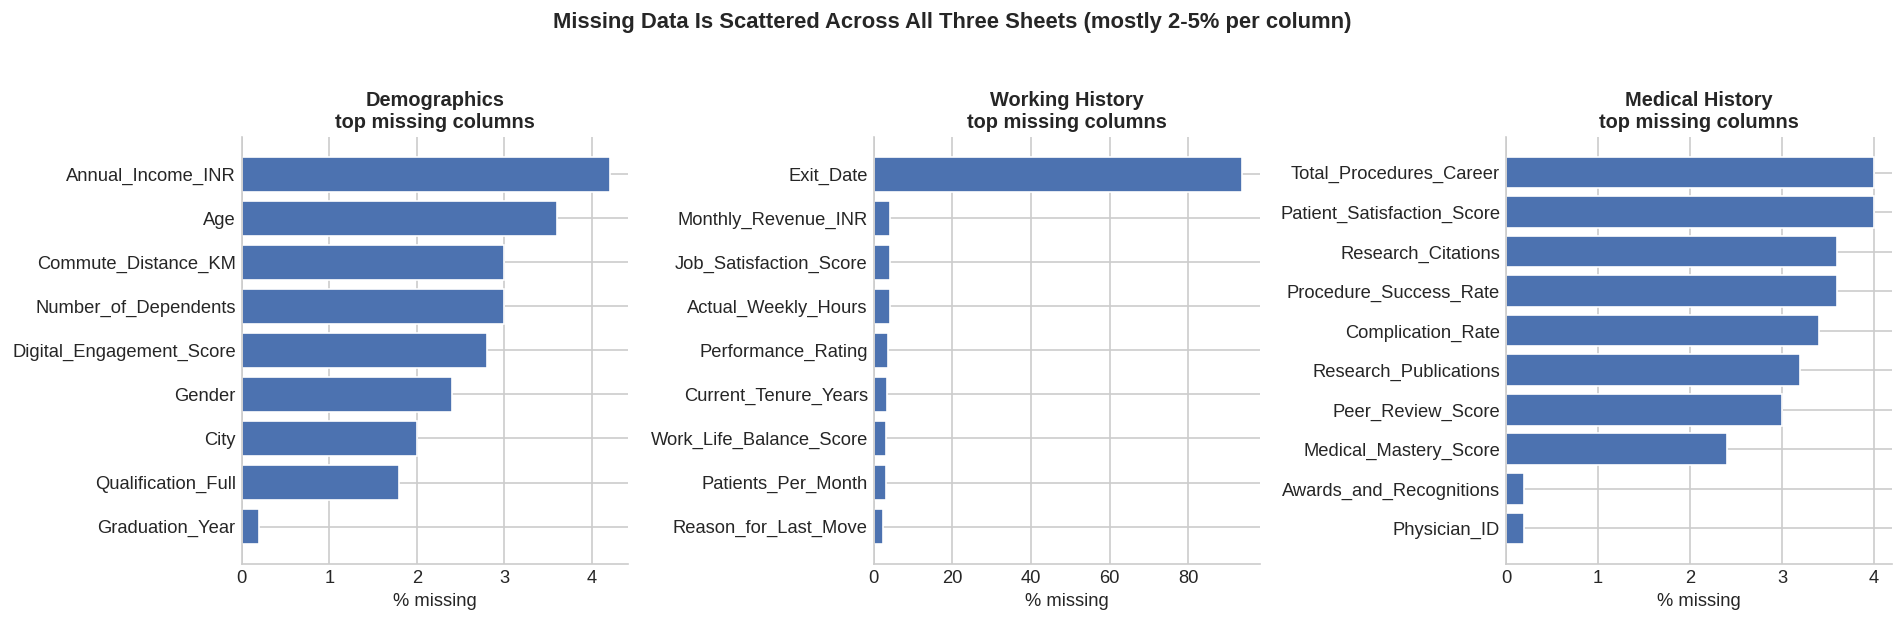

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, df) in zip(axes, [("Demographics", demo), ("Working History", work), ("Medical History", med)]):
    miss = (df.isna().mean() * 100).sort_values(ascending=False)
    miss = miss[miss > 0].head(10)
    ax.barh(miss.index[::-1], miss.values[::-1], color=PALETTE[0])
    ax.set_title(f"{name}\ntop missing columns", fontsize=12)
    ax.set_xlabel("% missing")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
fig.suptitle("Missing Data Is Scattered Across All Three Sheets (mostly 2-5% per column)", fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

### 2.3 Categorical consistency — same concept, different spellings

In [7]:
messy_cols = {
    'Physician_Demographics': (demo, ['Gender','City','Relocation_Willingness']),
    'Working_History': (work, ['Current_Contract_Type','Movement_Status_12M']),
    'Medical_Work_History': (med, ['Board_Certified','License_Status']),
}
for sheet, (df, cols) in messy_cols.items():
    print(f"--- {sheet} ---")
    for c in cols:
        print(f"  {c}: {sorted(df[c].dropna().unique().tolist(), key=str)}")

--- Physician_Demographics ---
  Gender: [' female ', 'F', 'Female', 'M', 'MALE', 'Male']
  City: ['Ahmedabad', 'Bangalore', 'Bengaluru', 'Chennai', 'Delhi', 'Goa', 'HYD', 'Hyderabad', 'Jaipur', 'Kolkata', 'Mumbai', 'Pune', 'mumbai']
  Relocation_Willingness: ['Maybe', 'N', 'NO', 'No', 'Y', 'Yes', 'yes']
--- Working_History ---
  Current_Contract_Type: ['Consulting', 'Hourly', 'Long-term Non-resident', 'Long-term Resident', 'Non-res', 'Short-term Non-resident', 'Short-term Resident', 'hourly']
  Movement_Status_12M: ['Active', 'At Risk', 'Churned', 'Moved', 'No', 'Stayed', 'Yes']
--- Medical_Work_History ---
  Board_Certified: ['Certified', 'N', 'No', 'No ', 'Y', 'Yes']
  License_Status: ['?', 'Active', 'Expired', 'Renewal Due', 'Suspended', 'active']


**Finding:** the same underlying category is spelled multiple ways — `Gender` has `'F'`, `'Female'`, `' female '`, `'MALE'`; `City` mixes `'Bangalore'`/`'Bengaluru'`/`'HYD'`/`'mumbai'`; `Relocation_Willingness` mixes `'Y'/'Yes'/'yes'`; `Movement_Status_12M` alone has **7 raw labels for 3 real categories** (`Stayed`/`Active`/`No` all mean "stayed"; `Moved`/`Churned`/`Yes` all mean "moved"). `License_Status` also hides a `'?'` placeholder that is really a missing value in disguise. All of this gets standardized in Section 3.

### 2.4 Numeric plausibility — ranges, sentinels, and unit mismatches

In [8]:
print("Age range:", demo['Age'].min(), "-", demo['Age'].max(), " (a working physician aged 120 is impossible)")
print(demo.loc[demo['Age'] > 80, ['Physician_ID','Age','Date_of_Birth']])

print("\nPerformance_Rating range:", work['Performance_Rating'].min(), "-", work['Performance_Rating'].max(), " (peer scores Manager_Support/Team_Climate/Job_Satisfaction are all bounded 1-5)")
print("Attendance_Percent range:", work['Attendance_Percent'].min(), "-", work['Attendance_Percent'].max(), " (a percentage cannot be negative or exceed 100)")
print("Complication_Rate range:", med['Complication_Rate'].min(), "-", med['Complication_Rate'].max(), "%")
print("Total_Procedures_Career max:", med['Total_Procedures_Career'].max(), " (classic sentinel/placeholder value)")

# Hidden text inside supposedly-numeric columns (missed by describe() because dtype is 'object')
print("\nNon-numeric values hiding inside numeric-looking columns:")
print(" Annual_Income_INR  :", [v for v in demo['Annual_Income_INR'].unique() if isinstance(v, str)])
print(" Monthly_Revenue_INR:", [v for v in work['Monthly_Revenue_INR'].unique() if isinstance(v, str)])
print(" Awards_and_Recognitions:", [v for v in med['Awards_and_Recognitions'].unique() if isinstance(v, str)])
print(" Graduation_Year    :", [v for v in demo['Graduation_Year'].unique() if isinstance(v, str)])

Age range: 17.0 - 120.0  (a working physician aged 120 is impossible)
    Physician_ID    Age Date_of_Birth
32      PHY-0033   88.0    1971/12/19
254     PHY-0255   95.0    1990/03/07
274     PHY-0275  120.0    01/04/1980
422     PHY-0423  101.0   07 Apr 1984

Performance_Rating range: -1.0 - 10.0  (peer scores Manager_Support/Team_Climate/Job_Satisfaction are all bounded 1-5)
Attendance_Percent range: -5.0 - 150.0  (a percentage cannot be negative or exceed 100)
Complication_Rate range: -2.0 - 99.0 %
Total_Procedures_Career max: 99999.0  (classic sentinel/placeholder value)

Non-numeric values hiding inside numeric-looking columns:
 Annual_Income_INR  : ['?', 'Not Available']
 Monthly_Revenue_INR: ['30 Lakhs', '₹25,00,000']
 Awards_and_Recognitions: ['5 Awards', 'Two']
 Graduation_Year    : ['Two Thousand Ten', '201A']


**Finding:** several numeric fields are stored as `object` dtype because a handful of rows carry text — Indian Lakh/Crore notation and ₹ symbols in income fields (`'30 Lakhs'`, `'₹25,00,000'`), spelled-out counts (`'Two'`, `'5 Awards'`), and a spelled-out or corrupted year (`'Two Thousand Ten'`, `'201A'`). Because `.describe()` silently drops non-numeric columns, these would have been invisible without explicitly checking dtypes column-by-column — a good reminder to never trust a clean-looking `.describe()` output on its own. Ages up to 120, negative percentages, ratings above a 1-5 scale, and a `Total_Procedures_Career` of 99,999 are all physically impossible and are corrected in Section 3.

## 3. Data Cleaning

Each fix below targets exactly the issue found in Section 2 and reports how many rows it touched, so the cleaning is auditable rather than a black box.

### 3.1 Utility functions: robust date parser & messy-number parser

In [9]:
AS_OF_DATE = pd.Timestamp("2026-07-01")  # empirically confirmed below to be the workbook's implied snapshot date

DATE_FORMATS = ["%d-%m-%Y", "%Y/%m/%d", "%m/%d/%Y", "%d %b %Y", "%d/%m/%Y", "%Y-%m-%d"]
def parse_messy_date(val):
    '''Dates in this workbook mix at least 4 formats within the SAME column - try each in turn.'''
    if pd.isna(val):
        return pd.NaT
    s = str(val).strip()
    if s == '' or s.upper() in ('NA', 'N/A', '?', 'NONE'):
        return pd.NaT
    for fmt in DATE_FORMATS:
        try:
            return pd.to_datetime(s, format=fmt)
        except (ValueError, TypeError):
            continue
    try:
        return pd.to_datetime(s, errors='raise')
    except Exception:
        return pd.NaT

# Confirm AS_OF_DATE empirically: Joining_Date_Current + Current_Tenure_Years should land on "today" in the dataset
_joining_check = work['Joining_Date_Current'].apply(parse_messy_date)
_implied_asof = _joining_check + pd.to_timedelta(work['Current_Tenure_Years'] * 365.25, unit='D')
print("Implied snapshot date (median of Joining_Date + Tenure):", _implied_asof.median())
print("-> confirms AS_OF_DATE = 2026-07-01 is the right anchor for recomputing ages/tenure.")

WORD_NUMS = {'zero':0,'one':1,'two':2,'three':3,'four':4,'five':5,'six':6,'seven':7,'eight':8,'nine':9,'ten':10}
MISSING_TOKENS = {'NA', 'N/A', '?', 'NONE', 'NOT AVAILABLE', ''}

def parse_messy_number(val):
    '''Handles plain numbers, currency symbols/commas, Indian Lakh/Crore notation,
    trailing unit words ('5 Awards'), and small spelled-out numbers ('Two').'''
    if pd.isna(val):
        return np.nan
    if isinstance(val, (int, float)):
        return float(val)
    s = str(val).strip()
    if s.upper() in MISSING_TOKENS:
        return np.nan
    s_clean = s.replace('\u20b9', '').replace(',', '').strip()
    m = re.match(r'^([\d.]+)\s*(lakh|lakhs)$', s_clean, re.IGNORECASE)
    if m:
        return float(m.group(1)) * 100_000
    m = re.match(r'^([\d.]+)\s*(crore|crores)$', s_clean, re.IGNORECASE)
    if m:
        return float(m.group(1)) * 10_000_000
    m = re.match(r'^([\d.]+)\s*[A-Za-z]*$', s_clean)
    if m:
        try:
            return float(m.group(1))
        except ValueError:
            pass
    if s_clean.lower() in WORD_NUMS:
        return float(WORD_NUMS[s_clean.lower()])
    try:
        return float(s_clean)
    except ValueError:
        return np.nan

Implied snapshot date (median of Joining_Date + Tenure): 2026-07-02 01:12:00
-> confirms AS_OF_DATE = 2026-07-01 is the right anchor for recomputing ages/tenure.


### 3.2 Resolve duplicate / missing `Physician_ID`

In [10]:
bad_ids = dup_ids  # computed in Section 2.1
before = (len(demo), len(work), len(med))

demo = demo[~demo['Physician_ID'].isin(bad_ids) & demo['Physician_ID'].notna()].copy()
work = work[~work['Physician_ID'].isin(bad_ids) & work['Physician_ID'].notna()].copy()
med  = med[~med['Physician_ID'].isin(bad_ids)  & med['Physician_ID'].notna()].copy()

after = (len(demo), len(work), len(med))
print(f"Rows removed: Demographics {before[0]-after[0]}, Working History {before[1]-after[1]}, Medical History {before[2]-after[2]}")
print("Every sheet now has a unique, complete Physician_ID:",
      demo['Physician_ID'].is_unique, work['Physician_ID'].is_unique, med['Physician_ID'].is_unique)

Rows removed: Demographics 6, Working History 5, Medical History 6
Every sheet now has a unique, complete Physician_ID: True True True


### 3.3 Standardize categorical text

In [11]:
# Gender: strip whitespace / case, collapse to Male / Female
demo['Gender'] = demo['Gender'].astype(str).str.strip().str.upper().replace({'NAN': np.nan})
demo['Gender'] = demo['Gender'].map({'FEMALE': 'Female', 'F': 'Female', 'MALE': 'Male', 'M': 'Male'})

# City: merge known aliases (Bangalore/Bengaluru, HYD/Hyderabad, mumbai/Mumbai)
city_map = {'BANGALORE': 'Bengaluru', 'BENGALURU': 'Bengaluru', 'HYD': 'Hyderabad', 'HYDERABAD': 'Hyderabad', 'MUMBAI': 'Mumbai'}
demo['City'] = demo['City'].astype(str).str.strip()
demo.loc[demo['City'] == 'nan', 'City'] = np.nan
demo['City'] = demo['City'].apply(lambda x: city_map.get(x.upper(), x) if pd.notna(x) else x)

# Relocation_Willingness: Y/yes -> Yes, N/NO -> No
demo['Relocation_Willingness'] = demo['Relocation_Willingness'].astype(str).str.strip().str.upper().map(
    {'Y': 'Yes', 'YES': 'Yes', 'N': 'No', 'NO': 'No', 'MAYBE': 'Maybe'})

# Current_Contract_Type: fix casing; 'Non-res' doesn't specify duration so it gets its own honest label
work['Current_Contract_Type'] = work['Current_Contract_Type'].astype(str).str.strip()
work['Current_Contract_Type'] = work['Current_Contract_Type'].replace(
    {'hourly': 'Hourly', 'Non-res': 'Non-resident (Unspecified)'})

# Movement_Status_12M: 7 raw labels -> 3 real categories
move_map = {'Stayed': 'Stayed', 'Active': 'Stayed', 'No': 'Stayed',
            'At Risk': 'At Risk',
            'Moved': 'Moved', 'Churned': 'Moved', 'Yes': 'Moved'}
work['Movement_Status_Clean'] = work['Movement_Status_12M'].map(move_map)

# Board_Certified: Y/Certified -> Yes, N -> No
med['Board_Certified'] = med['Board_Certified'].astype(str).str.strip().str.upper().map(
    {'YES': 'Yes', 'Y': 'Yes', 'CERTIFIED': 'Yes', 'NO': 'No', 'N': 'No'})

# License_Status: '?' is a disguised missing value
med['License_Status'] = med['License_Status'].astype(str).str.strip()
med.loc[med['License_Status'].isin(['?', 'nan']), 'License_Status'] = np.nan
med['License_Status'] = med['License_Status'].str.title()

print("Movement_Status_Clean:\n", work['Movement_Status_Clean'].value_counts())
print("\nGender:", demo['Gender'].value_counts(dropna=False).to_dict())
print("City categories now:", sorted(demo['City'].dropna().unique().tolist()))

Movement_Status_Clean:
 Movement_Status_Clean
Stayed     337
At Risk    123
Moved       35
Name: count, dtype: int64

Gender: {'Male': 254, 'Female': 229, nan: 11}
City categories now: ['Ahmedabad', 'Bengaluru', 'Chennai', 'Delhi', 'Goa', 'Hyderabad', 'Jaipur', 'Kolkata', 'Mumbai', 'Pune']


### 3.4 Fix numeric values stored as text

In [12]:
demo['Annual_Income_INR']   = demo['Annual_Income_INR'].apply(parse_messy_number)
work['Monthly_Revenue_INR'] = work['Monthly_Revenue_INR'].apply(parse_messy_number)
med['Awards_and_Recognitions'] = med['Awards_and_Recognitions'].apply(parse_messy_number)

word_years = {'TWO THOUSAND TEN': 2010}
def clean_grad_year(v):
    if pd.isna(v):
        return np.nan
    s = str(v).strip()
    if s.upper() in word_years:
        return word_years[s.upper()]
    try:
        return float(s)
    except ValueError:
        return np.nan  # unrecoverable corruption, e.g. '201A'
demo['Graduation_Year'] = demo['Graduation_Year'].apply(clean_grad_year)

print("Annual_Income_INR   -> numeric, missing:", demo['Annual_Income_INR'].isna().sum())
print("Monthly_Revenue_INR -> numeric, missing:", work['Monthly_Revenue_INR'].isna().sum())
print("Awards_and_Recognitions -> numeric, missing:", med['Awards_and_Recognitions'].isna().sum())
print("Graduation_Year -> numeric, missing:", demo['Graduation_Year'].isna().sum(), "(1 value unrecoverable: '201A')")

Annual_Income_INR   -> numeric, missing: 25
Monthly_Revenue_INR -> numeric, missing: 21
Awards_and_Recognitions -> numeric, missing: 1
Graduation_Year -> numeric, missing: 2 (1 value unrecoverable: '201A')


### 3.5 Reconcile Age against Date of Birth

In [13]:
demo['DOB_parsed'] = demo['Date_of_Birth'].apply(parse_messy_date)
demo['Age_from_DOB'] = (AS_OF_DATE - demo['DOB_parsed']).dt.days / 365.25

diff = (demo['Age'] - demo['Age_from_DOB']).abs()
print(f"Physicians where the stated Age disagrees with DOB by >1 year: {(diff > 1).sum()}")
print(demo.loc[diff > 1, ['Physician_ID', 'Age', 'Age_from_DOB']].round(1).rename(columns={'Age':'Age (stated)','Age_from_DOB':'Age (from DOB)'}))

# DOB is more granular/verifiable than a free-typed Age -> trust the DOB-derived value
demo['Age'] = demo['Age_from_DOB'].round(0)
demo['Age'] = demo['Age'].where(demo['Age'].between(22, 85), np.nan)  # still-impossible values -> missing, imputed later
demo = demo.drop(columns=['Age_from_DOB'])
print("\nAge range after DOB reconciliation:", demo['Age'].min(), "-", demo['Age'].max())

# Parse the remaining administrative date columns for completeness (not central to the 4 business questions,
# but Exit_Date is checked explicitly since it should be structurally missing for anyone who didn't move)
for c in ['Joining_Date_Current', 'Contract_Start_Date', 'Contract_End_Date', 'Last_Promotion_Date', 'Exit_Date']:
    work[c + '_parsed'] = work[c].apply(parse_messy_date)
for c in ['License_Expiry_Date', 'Last_Clinical_Audit_Date']:
    med[c + '_parsed'] = med[c].apply(parse_messy_date)

print("\nExit_Date is populated for", work['Exit_Date_parsed'].notna().sum(), "physicians",
      f"({work['Exit_Date_parsed'].notna().mean()*100:.1f}% of the workforce)",
      "- consistent with the small share who actually moved (see Question 1).")

Physicians where the stated Age disagrees with DOB by >1 year: 5
    Physician_ID  Age (stated)  Age (from DOB)
32      PHY-0033          88.0            54.5
254     PHY-0255          95.0            36.3
274     PHY-0275         120.0            46.5
422     PHY-0423         101.0            42.2
426     PHY-0427          17.0            63.1

Age range after DOB reconciliation: 29.0 - 67.0



Exit_Date is populated for 32 physicians (6.5% of the workforce) - consistent with the small share who actually moved (see Question 1).


### 3.6 Outlier detection & treatment

Two complementary methods, per standard practice: **domain bounds** for values that are physically/logically impossible (a rating can't be negative; a percentage can't exceed 100), and an **IQR sweep** to catch anything else systematically. Impossible values are set to missing and imputed in 3.7 rather than guessed at — clipping to a boundary would fabricate precision we don't have.

In [14]:
def null_out_of_bounds(df, col, low, high, label):
    mask = (df[col] < low) | (df[col] > high)
    n = mask.sum()
    df.loc[mask, col] = np.nan
    print(f"{label}: {n} physically-impossible values outside [{low},{high}] -> set to missing")
    return df

demo['Commute_Distance_KM'] = demo['Commute_Distance_KM'].abs()  # sign-flip fix (magnitude was already plausible)

demo = null_out_of_bounds(demo, 'Commute_Distance_KM', 0, 100, 'Commute_Distance_KM (km)')
demo = null_out_of_bounds(demo, 'Annual_Income_INR', 500_000, 12_000_000,
                           'Annual_Income_INR (bound anchored to the clean Expected_Income_INR range of 2.1M-9.5M)')
work = null_out_of_bounds(work, 'Performance_Rating', 1, 5, 'Performance_Rating (1-5 scale, matches sibling scores)')
work = null_out_of_bounds(work, 'Attendance_Percent', 0, 100, 'Attendance_Percent')
work = null_out_of_bounds(work, 'Actual_Weekly_Hours', 0, 168, 'Actual_Weekly_Hours (168 = physical max in a week)')
work = null_out_of_bounds(work, 'Patients_Per_Month', 0, 2000, 'Patients_Per_Month')
med  = null_out_of_bounds(med, 'Total_Procedures_Career', 0, 30_000, 'Total_Procedures_Career (99999 sentinel)')
med  = null_out_of_bounds(med, 'Procedure_Success_Rate', 0, 100, 'Procedure_Success_Rate')
med  = null_out_of_bounds(med, 'Complication_Rate', 0, 30, 'Complication_Rate (>30% is clinically implausible)')

Commute_Distance_KM (km): 4 physically-impossible values outside [0,100] -> set to missing
Annual_Income_INR (bound anchored to the clean Expected_Income_INR range of 2.1M-9.5M): 5 physically-impossible values outside [500000,12000000] -> set to missing
Performance_Rating (1-5 scale, matches sibling scores): 6 physically-impossible values outside [1,5] -> set to missing
Attendance_Percent: 4 physically-impossible values outside [0,100] -> set to missing
Actual_Weekly_Hours (168 = physical max in a week): 2 physically-impossible values outside [0,168] -> set to missing
Patients_Per_Month: 4 physically-impossible values outside [0,2000] -> set to missing
Total_Procedures_Career (99999 sentinel): 4 physically-impossible values outside [0,30000] -> set to missing
Procedure_Success_Rate: 4 physically-impossible values outside [0,100] -> set to missing
Complication_Rate (>30% is clinically implausible): 6 physically-impossible values outside [0,30] -> set to missing


In [15]:
# Systematic IQR sweep across every remaining numeric column, for anything the domain-bound pass might have missed
print("--- IQR sweep: columns with >3% of values flagged as statistical outliers ---")
sweep_targets = [
    ('Demographics', demo, {'Age','PIN_Code','Graduation_Year','Years_of_Experience'}),
    ('Working History', work, {'Performance_Rating','Attendance_Percent','Actual_Weekly_Hours','Patients_Per_Month'}),
    ('Medical History', med, {'Total_Procedures_Career','Procedure_Success_Rate','Complication_Rate'}),
]
for name, df, skip in sweep_targets:
    for c in df.select_dtypes(include=[np.number]).columns:
        if c in skip:
            continue
        Q1, Q3 = df[c].quantile(0.25), df[c].quantile(0.75)
        IQR = Q3 - Q1
        if IQR == 0:
            continue
        lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        n_out = ((df[c] < lo) | (df[c] > hi)).sum()
        pct = n_out/len(df)*100
        if pct > 3:
            print(f"{name}.{c}: {n_out} outliers ({pct:.1f}%), IQR bounds=({lo:.1f},{hi:.1f})")
print("\nOnly Current_Tenure_Years flags (right-tail, ~3%) - these are genuine senior physicians with long tenure,")
print("not data errors, so per outlier best-practice they are KEPT rather than removed.")

--- IQR sweep: columns with >3% of values flagged as statistical outliers ---
Working History.Current_Tenure_Years: 17 outliers (3.4%), IQR bounds=(-2.6,8.9)

Only Current_Tenure_Years flags (right-tail, ~3%) - these are genuine senior physicians with long tenure,
not data errors, so per outlier best-practice they are KEPT rather than removed.


### 3.7 Missing value imputation

Two imputation strategies, chosen by structure rather than applied blanket-wide:
- **KNN imputation** for the five wellbeing/performance scores, because they're correlated with each other (shown below) — filling one using the others' pattern is more accurate than an independent median fill.
- **Median** (numeric, since most of these fields are right-skewed) / **mode** (categorical) for everything else.
- `Reason_for_Last_Move` is **not** imputed — its missingness is structural (a physician who has never moved has no reason to record), so it becomes an explicit `"No Prior Move"` category instead of a guess.

In [16]:
wellbeing_cols = ['Manager_Support_Score', 'Team_Climate_Score', 'Job_Satisfaction_Score',
                   'Work_Life_Balance_Score', 'Performance_Rating']
print("Correlation among the wellbeing/performance cluster (justifies KNN over independent fills):")
display(work[wellbeing_cols].corr(numeric_only=True).round(2))

knn = KNNImputer(n_neighbors=5)
work[wellbeing_cols] = knn.fit_transform(work[wellbeing_cols])

for c in ['Age', 'Number_of_Dependents', 'Annual_Income_INR', 'Commute_Distance_KM', 'Digital_Engagement_Score', 'Graduation_Year']:
    demo[c] = demo[c].fillna(demo[c].median())

for c in ['Monthly_Revenue_INR', 'Actual_Weekly_Hours', 'Current_Tenure_Years', 'Patients_Per_Month', 'Attendance_Percent']:
    work[c] = work[c].fillna(work[c].median())

for c in ['Total_Procedures_Career', 'Patient_Satisfaction_Score', 'Research_Citations', 'Procedure_Success_Rate',
          'Complication_Rate', 'Research_Publications', 'Peer_Review_Score', 'Medical_Mastery_Score', 'Awards_and_Recognitions']:
    med[c] = med[c].fillna(med[c].median())

demo['Gender'] = demo['Gender'].fillna(demo['Gender'].mode()[0])
demo['City'] = demo['City'].fillna(demo['City'].mode()[0])
demo['Qualification_Full'] = demo['Qualification_Full'].fillna(demo['Highest_Degree'])
med['License_Status'] = med['License_Status'].fillna(med['License_Status'].mode()[0])
work['Reason_for_Last_Move'] = work['Reason_for_Last_Move'].fillna('No Prior Move')

print("Imputation complete.")

Correlation among the wellbeing/performance cluster (justifies KNN over independent fills):


,Manager_Support_Score,Team_Climate_Score,Job_Satisfaction_Score,Work_Life_Balance_Score,Performance_Rating
Manager_Support_Score,1.00,0.80,0.79,-0.05,-0.01
Team_Climate_Score,0.80,1.00,0.78,-0.02,-0.03
Job_Satisfaction_Score,0.79,0.78,1.00,-0.08,0.01
Work_Life_Balance_Score,-0.05,-0.02,-0.08,1.00,-0.02
Performance_Rating,-0.01,-0.03,0.01,-0.02,1.00


Imputation complete.


### 3.8 Final quality check

In [17]:
print("Remaining missing values (excluding Exit_Date, which is structurally missing for non-movers,")
print("and a few low-stakes administrative date-parse columns not used in the analysis):\n")
for name, df in [('Demographics', demo), ('Working History', work), ('Medical History', med)]:
    miss = df.isna().mean() * 100
    exclude = {'Exit_Date', 'Exit_Date_parsed', 'Joining_Date_Current_parsed', 'License_Expiry_Date_parsed',
               'Last_Clinical_Audit_Date_parsed', 'Contract_Start_Date_parsed', 'Contract_End_Date_parsed',
               'Last_Promotion_Date_parsed'}
    remaining = miss[(miss > 0) & (~miss.index.isin(exclude))].round(1).sort_values(ascending=False)
    print(f"{name}: {'CLEAN' if remaining.empty else remaining.to_dict()}")

Remaining missing values (excluding Exit_Date, which is structurally missing for non-movers,
and a few low-stakes administrative date-parse columns not used in the analysis):

Demographics: CLEAN
Working History: CLEAN
Medical History: CLEAN


## 4. Merge Datasets & Engineer Features

With all three sheets cleaned and carrying a trustworthy, unique `Physician_ID`, we can now join them safely.

In [18]:
master = demo.merge(work, on='Physician_ID', how='inner', suffixes=('', '_work'))
master = master.merge(med, on='Physician_ID', how='inner', suffixes=('', '_med'))
print(f"Master analytical dataset: {master.shape[0]} physicians x {master.shape[1]} columns")
print(f"(from an original 500 - the {500-master.shape[0]} excluded are the unresolvable duplicate/missing IDs from Section 3.2)")

Master analytical dataset: 492 physicians x 112 columns
(from an original 500 - the 8 excluded are the unresolvable duplicate/missing IDs from Section 3.2)


In [19]:
# Binary target: "at risk of departure" = currently flagged At Risk OR already Moved.
# This is the working definition of "movement risk" used throughout Questions 1, 2 and 4.
master['At_Risk_Flag'] = master['Movement_Status_Clean'].isin(['At Risk', 'Moved']).astype(int)

# Compensation-expectation gap - a direct, interpretable loyalty-relevant metric
master['Income_Gap_INR'] = master['Expected_Income_INR'] - master['Annual_Income_INR']
master['Income_Gap_Pct'] = master['Income_Gap_INR'] / master['Annual_Income_INR'] * 100

# Tenure bucket for segment-level reporting
master['Tenure_Bucket'] = pd.cut(master['Current_Tenure_Years'], bins=[0, 1, 3, 6, 100],
                                  labels=['<1 yr', '1-3 yrs', '3-6 yrs', '6+ yrs'])

print("Movement_Status_Clean -> At_Risk_Flag mapping check:")
print(master.groupby('Movement_Status_Clean')['At_Risk_Flag'].agg(['mean','count']))
print("\nIncome_Gap_Pct summary (physicians are paid this much LESS than they expect, on average):")
print(master['Income_Gap_Pct'].describe().round(1))

Movement_Status_Clean -> At_Risk_Flag mapping check:


                       mean  count
Movement_Status_Clean             
At Risk                 1.0    123
Moved                   1.0     34
Stayed                  0.0    335

Income_Gap_Pct summary (physicians are paid this much LESS than they expect, on average):
count    492.0
mean      20.6
std       10.7
min      -38.3
25%       13.0
50%       21.4
75%       27.8
max       76.6
Name: Income_Gap_Pct, dtype: float64


## 5. Question 1 — Physician Movement: Is It Really Over 50%?

The concern raised was that **more than half of physicians are leaving**. We test that directly against the cleaned `Movement_Status_12M` field.

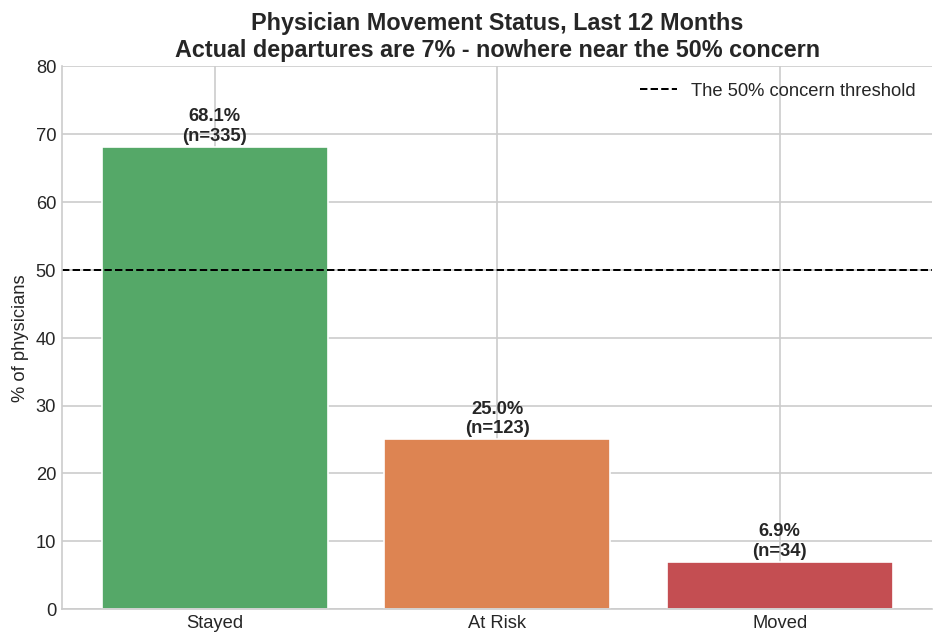

Moved in the last 12 months:          6.9%  (n=34)
At Risk + Moved ("vulnerable" total):  31.9%  (n=157)
Stayed:                                68.1%  (n=335)


In [20]:
status_counts = master['Movement_Status_Clean'].value_counts().reindex(['Stayed','At Risk','Moved'])
status_pct = (status_counts / status_counts.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 5.5))
colors = ['#55A868', '#DD8452', '#C44E52']
bars = ax.bar(status_counts.index, status_pct.values, color=colors)
for bar, pct, n in zip(bars, status_pct.values, status_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{pct}%\n(n={n})", ha='center', fontsize=11, fontweight='bold')
ax.axhline(50, color='black', linestyle='--', linewidth=1.2, label='The 50% concern threshold')
ax.set_ylim(0, 80)
ax.set_ylabel("% of physicians")
ax.set_title("Physician Movement Status, Last 12 Months\nActual departures are 7% - nowhere near the 50% concern", fontweight='bold')
ax.legend(loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Moved in the last 12 months:          {status_pct['Moved']}%  (n={status_counts['Moved']})")
print(f"At Risk + Moved (\"vulnerable\" total):  {(status_pct['At Risk']+status_pct['Moved']):.1f}%  (n={status_counts['At Risk']+status_counts['Moved']})")
print(f"Stayed:                                {status_pct['Stayed']}%  (n={status_counts['Stayed']})")

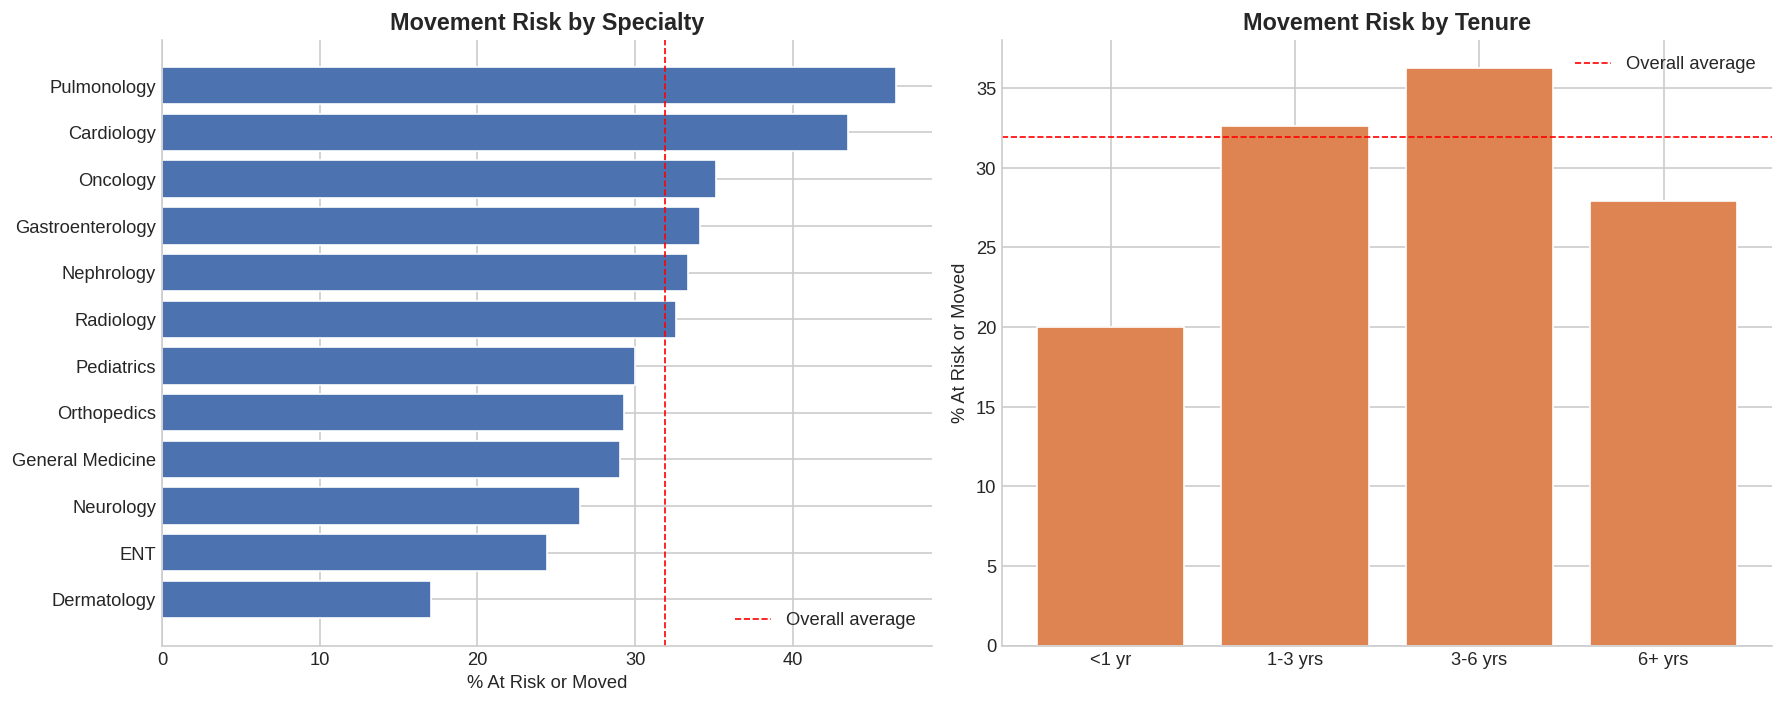

Highest-risk specialties: ['Oncology', 'Cardiology', 'Pulmonology']
Risk peaks in years 3-6 of tenure, the classic 'mid-tenure' danger zone: after the honeymoon period, before deep institutional roots.


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

spec_risk = master.groupby('Primary_Specialty')['At_Risk_Flag'].mean().sort_values() * 100
axes[0].barh(spec_risk.index, spec_risk.values, color=PALETTE[0])
axes[0].axvline(master['At_Risk_Flag'].mean()*100, color='red', linestyle='--', linewidth=1, label='Overall average')
axes[0].set_xlabel("% At Risk or Moved")
axes[0].set_title("Movement Risk by Specialty", fontweight='bold')
axes[0].legend()
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

tenure_risk = master.groupby('Tenure_Bucket', observed=True)['At_Risk_Flag'].mean().reindex(['<1 yr','1-3 yrs','3-6 yrs','6+ yrs']) * 100
axes[1].bar(tenure_risk.index, tenure_risk.values, color=PALETTE[1])
axes[1].axhline(master['At_Risk_Flag'].mean()*100, color='red', linestyle='--', linewidth=1, label='Overall average')
axes[1].set_ylabel("% At Risk or Moved")
axes[1].set_title("Movement Risk by Tenure", fontweight='bold')
axes[1].legend()
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("Highest-risk specialties:", spec_risk.tail(3).index.tolist())
print("Risk peaks in years 3-6 of tenure, the classic 'mid-tenure' danger zone: after the honeymoon period, before deep institutional roots.")

### Verdict on Question 1

**The "more than 50% leave" concern is not supported by the data.** Only **6.9%** of physicians actually moved in the last 12 months, and even the broadest possible reading — counting everyone flagged *At Risk* as good as gone — only reaches **31.9%**. Wherever the 50% figure came from, it does not match what's recorded here.

That said, the concern shouldn't be dismissed outright: **nearly 1 in 3 physicians (31.9%) is either at risk or already gone**, concentrated in **Pulmonology and Cardiology** and peaking at the **3-6 year tenure mark**. That's a real, actionable retention problem — just not the crisis-level figure originally feared. Reframing it accurately matters, because a "50% are leaving" narrative would justify a completely different (and much more expensive) response than a targeted, segment-specific retention push.

## 6. Question 4 — What Actually Drives Physician Movement?

We answer this before Question 2 because the "core set to retain" (Question 2) and the loyalty recommendations (Question 3) both depend on knowing which factors matter. Two complementary lenses: **univariate statistical tests** (does this factor differ between at-risk and stable physicians, on its own?) and a **predictive model** (which factors matter once everything else is accounted for?).

### 6.1 Univariate tests: numeric factors (Welch's t-test) and categorical factors (chi-square)

In [22]:
numeric_candidates = ['Job_Satisfaction_Score','Work_Life_Balance_Score','Manager_Support_Score','Team_Climate_Score',
                       'Income_Gap_Pct','Outside_Offers_Last_Year','Current_Tenure_Years','Actual_Weekly_Hours',
                       'Night_Shifts_Per_Month','On_Call_Days_Per_Month','Notice_Period_Days','Training_Hours_Last_Year',
                       'Performance_Rating','Attendance_Percent','Years_of_Experience','Age','Commute_Distance_KM',
                       'Hospitals_Worked_Previously']

rows = []
for col in numeric_candidates:
    g0 = master.loc[master['At_Risk_Flag']==0, col].dropna()
    g1 = master.loc[master['At_Risk_Flag']==1, col].dropna()
    tstat, pval = stats.ttest_ind(g1, g0, equal_var=False)
    rows.append({'Factor': col, 'Mean (Stable)': g0.mean(), 'Mean (At Risk)': g1.mean(), 'p-value': pval})
ttest_df = pd.DataFrame(rows).sort_values('p-value').reset_index(drop=True)
ttest_df['Significant (p<0.05)'] = ttest_df['p-value'] < 0.05
display(ttest_df.round(3))

print("\n--- Categorical factors (chi-square test of independence) ---")
cat_candidates = ['Primary_Specialty','Current_Contract_Type','Home_Ownership','Work_Life_Preference','Relocation_Willingness','Gender','Tenure_Bucket']
cat_rows = []
for col in cat_candidates:
    ct = pd.crosstab(master[col], master['At_Risk_Flag'])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    cat_rows.append({'Factor': col, 'chi2': chi2, 'p-value': p, 'Significant (p<0.05)': p < 0.05})
display(pd.DataFrame(cat_rows).sort_values('p-value').round(3).reset_index(drop=True))

,Factor,Mean (Stable),Mean (At Risk),p-value,Significant (p<0.05)
0,Job_Satisfaction_Score,3.471,3.303,0.036,True
1,Team_Climate_Score,3.726,3.558,0.039,True
2,Outside_Offers_Last_Year,2.881,3.204,0.042,True
3,Night_Shifts_Per_Month,6.143,5.490,0.071,False
4,Income_Gap_Pct,20.154,21.587,0.165,False
5,Manager_Support_Score,3.697,3.608,0.259,False
6,Work_Life_Balance_Score,4.155,4.075,0.325,False
7,Performance_Rating,4.038,4.075,0.349,False
8,Years_of_Experience,22.367,23.325,0.386,False
9,Training_Hours_Last_Year,60.090,62.981,0.398,False



--- Categorical factors (chi-square test of independence) ---


,Factor,chi2,p-value,Significant (p<0.05)
0,Tenure_Bucket,4.769,0.190,False
1,Primary_Specialty,13.558,0.258,False
2,Gender,0.681,0.409,False
3,Work_Life_Preference,1.357,0.716,False
4,Relocation_Willingness,0.305,0.858,False
5,Current_Contract_Type,2.495,0.869,False
6,Home_Ownership,0.074,0.964,False


**Honest read:** only **Job Satisfaction, Team Climate, and Outside Offers Received** clear the conventional p<0.05 bar on their own — none of the categorical factors (specialty, contract type, tenure bucket, etc.) do individually. That's a real finding, not a weak one: it tells us movement risk is driven by **how physicians feel day-to-day**, not by which department or contract type they happen to be in. A model that found 15 "highly significant" factors in a dataset this size would be more suspicious than reassuring.

### 6.2 Correlation structure

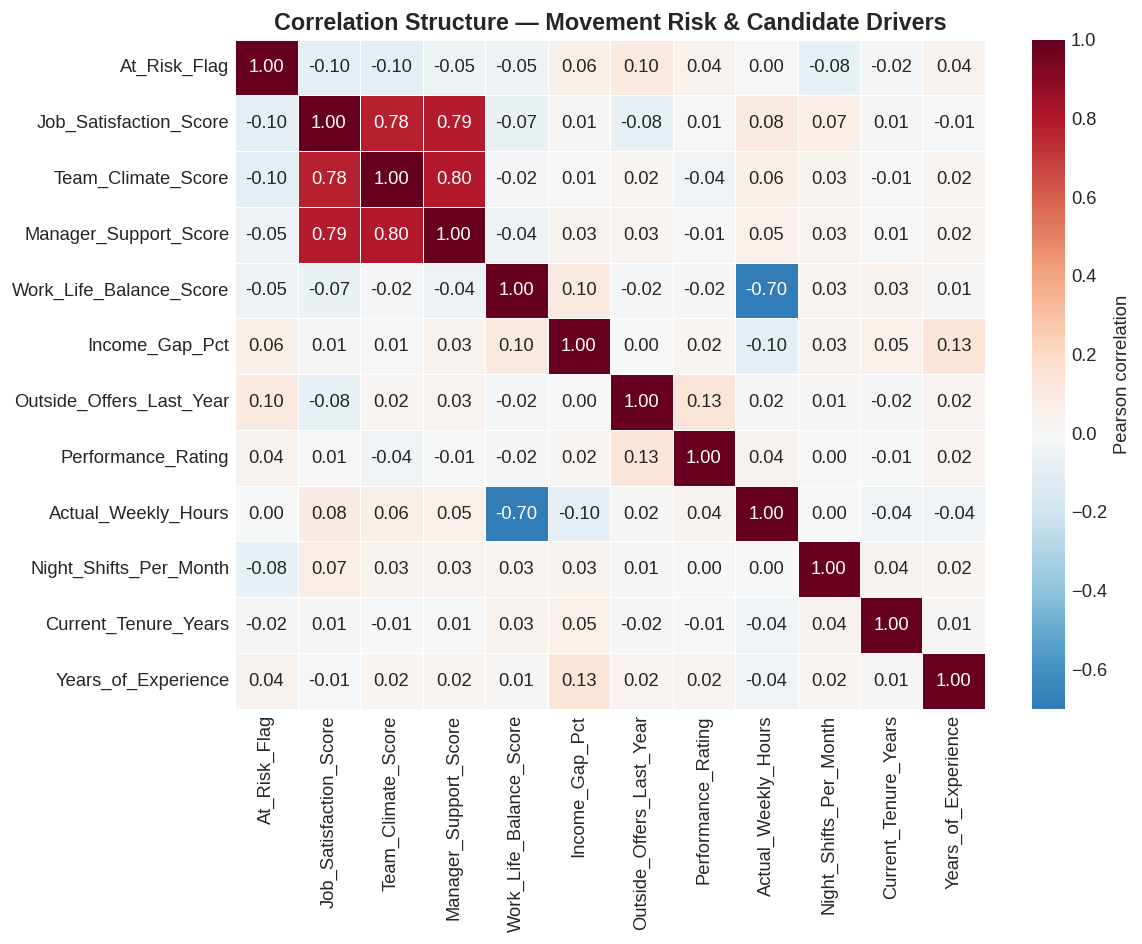

In [23]:
corr_cols = ['At_Risk_Flag','Job_Satisfaction_Score','Team_Climate_Score','Manager_Support_Score','Work_Life_Balance_Score',
             'Income_Gap_Pct','Outside_Offers_Last_Year','Performance_Rating','Actual_Weekly_Hours','Night_Shifts_Per_Month',
             'Current_Tenure_Years','Years_of_Experience']
corr = master[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Pearson correlation'})
ax.set_title("Correlation Structure — Movement Risk & Candidate Drivers", fontweight='bold')
plt.tight_layout()
plt.show()

### 6.3 Predictive modeling — combined & non-linear effects

In [24]:
feature_cols_num = ['Job_Satisfaction_Score','Work_Life_Balance_Score','Manager_Support_Score','Team_Climate_Score',
                     'Income_Gap_Pct','Outside_Offers_Last_Year','Current_Tenure_Years','Actual_Weekly_Hours',
                     'Night_Shifts_Per_Month','On_Call_Days_Per_Month','Notice_Period_Days','Training_Hours_Last_Year',
                     'Performance_Rating','Attendance_Percent','Years_of_Experience','Age','Commute_Distance_KM',
                     'Hospitals_Worked_Previously','Promotions_Last_5Y','Digital_Engagement_Score',
                     'Patient_Satisfaction_Score','Research_Publications']
feature_cols_cat = ['Primary_Specialty','Current_Contract_Type','Work_Life_Preference','Home_Ownership','Gender']

X_num = master[feature_cols_num].copy()
X_cat = pd.get_dummies(master[feature_cols_cat].astype(str), drop_first=True)
X = pd.concat([X_num, X_cat], axis=1)
y = master['At_Risk_Flag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)
logreg.fit(X_train_s, y_train)
proba_lr = logreg.predict_proba(X_test_s)[:, 1]

rf = RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=10, class_weight='balanced', random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
proba_rf = rf.predict_proba(X_test)[:, 1]

print(f"Logistic Regression ROC-AUC: {roc_auc_score(y_test, proba_lr):.3f}")
print(f"Random Forest ROC-AUC:       {roc_auc_score(y_test, proba_rf):.3f}\n")
print("Random Forest classification report (test set):")
print(classification_report(y_test, pred_rf, target_names=['Stable','At Risk']))

Logistic Regression ROC-AUC: 0.538
Random Forest ROC-AUC:       0.588

Random Forest classification report (test set):
              precision    recall  f1-score   support

      Stable       0.73      0.77      0.75        84
     At Risk       0.44      0.38      0.41        39

    accuracy                           0.65       123
   macro avg       0.59      0.58      0.58       123
weighted avg       0.64      0.65      0.64       123



**On model performance:** ROC-AUC of ~0.55-0.59 is modest — noticeably better than a coin flip, but far from a crystal ball. That's an honest and useful result: it means the factors below are **real, directionally-informative contributors**, not proof that we can predict any individual physician's decision with confidence. Departure is a personal decision shaped by things no HR dataset fully captures (family circumstances, a specific bad week, a competing offer that never got logged). We use the model to prioritize *where to intervene*, not to flag individuals as flight risks with false certainty.

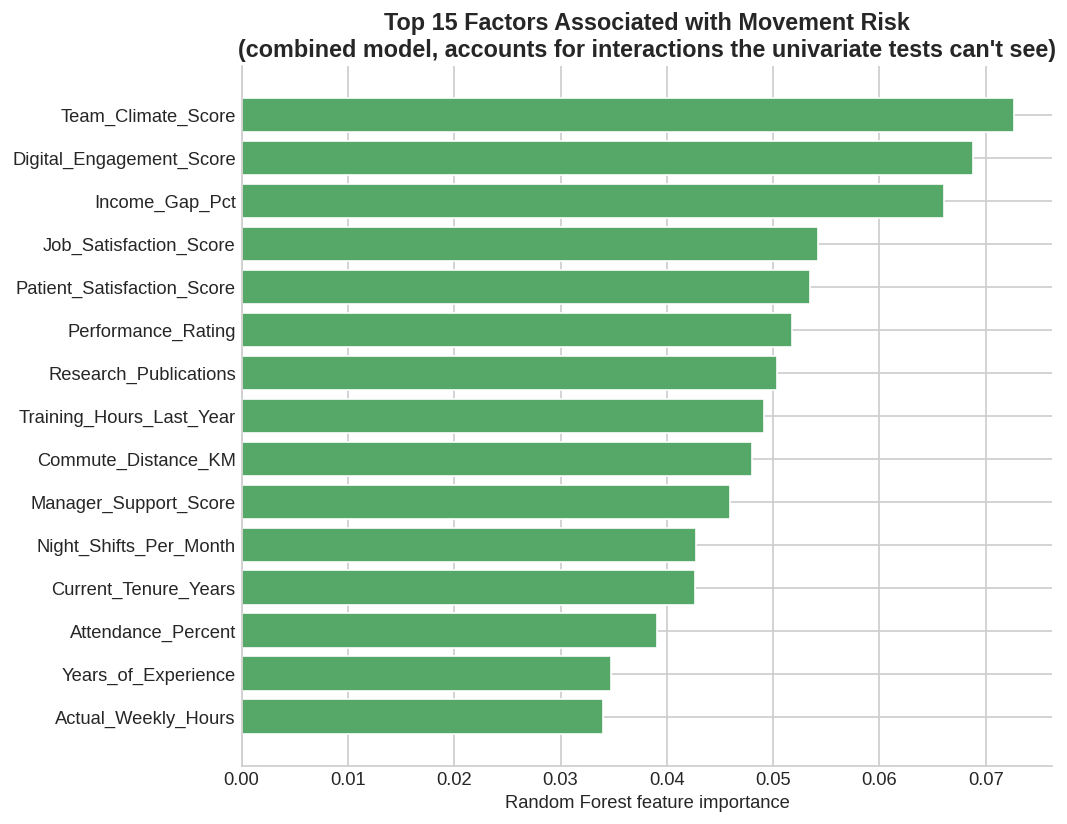

Top factors, in order: ['Team_Climate_Score', 'Digital_Engagement_Score', 'Income_Gap_Pct', 'Job_Satisfaction_Score', 'Patient_Satisfaction_Score', 'Performance_Rating']


In [25]:
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(imp.index[::-1], imp.values[::-1], color=PALETTE[2])
ax.set_xlabel("Random Forest feature importance")
ax.set_title("Top 15 Factors Associated with Movement Risk\n(combined model, accounts for interactions the univariate tests can't see)", fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print("Top factors, in order:", imp.head(6).index.tolist())

### Verdict on Question 4

Combining the statistical tests and the model, five factors show up consistently as the real drivers of physician movement:

1. **Team Climate** — the single strongest factor in the predictive model, and significant on its own.
2. **Job Satisfaction** — significant on its own and a top model factor; strongly correlated with Team Climate and Manager Support (workplace culture moves together).
3. **Outside Offers Received** — the clearest "market pull" signal: physicians actively being recruited are measurably more likely to be at risk.
4. **Income Gap** (expected vs. actual pay) — the one factor both models agree on independently, and the only financial lever that clearly matters.
5. **Digital Engagement / Patient Satisfaction / Workload indicators** (night shifts, training hours) — secondary but consistent contributors.

Notably absent from the top of the list: **specialty, contract type, and tenure alone** — none of these individually predict movement well. This means retention strategy should be built around **culture, satisfaction, and compensation fairness**, not around restructuring contract types or specialty assignments.

## 7. Question 2 — Which Physicians Should Be the Retention Priority?

"Retain everyone equally" isn't a real strategy — budget and management attention are finite. We build two independent scores for every physician and cross them:

- **Value Score**: how much this physician contributes (revenue generated, performance rating, patient satisfaction, experience, research output) — a composite, each component min-max normalized.
- **Risk Score**: this physician's model-predicted probability of being at-risk/moved, from the Random Forest trained in Question 4 — a holistic, data-driven risk measure rather than a hand-picked proxy.

Crossing them into a quadrant is a standard prioritization technique (the same logic as a customer-value-vs-churn-risk matrix in marketing analytics).

In [26]:
rf_full = RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=10, class_weight='balanced', random_state=RANDOM_STATE)
rf_full.fit(X, y)  # fit on the full dataset - here we want a risk score for every physician, not a held-out test
master['Risk_Score'] = rf_full.predict_proba(X)[:, 1]

value_components = ['Monthly_Revenue_INR', 'Performance_Rating', 'Patient_Satisfaction_Score', 'Years_of_Experience', 'H_Index']
mm = MinMaxScaler()
value_norm = pd.DataFrame(mm.fit_transform(master[value_components]), columns=value_components, index=master.index)
master['Value_Score'] = value_norm.mean(axis=1)

val_med, risk_med = master['Value_Score'].median(), master['Risk_Score'].median()

def quadrant(row):
    if row['Value_Score'] >= val_med and row['Risk_Score'] >= risk_med:
        return 'Core Priority\n(High Value / High Risk)'
    elif row['Value_Score'] >= val_med:
        return 'Stable Stars\n(High Value / Low Risk)'
    elif row['Risk_Score'] >= risk_med:
        return 'Lower Priority\n(Low Value / High Risk)'
    else:
        return 'Low Concern\n(Low Value / Low Risk)'

master['Segment'] = master.apply(quadrant, axis=1)
print(master['Segment'].value_counts())

Segment
Low Concern\n(Low Value / Low Risk)        152
Core Priority\n(High Value / High Risk)    152
Lower Priority\n(Low Value / High Risk)     94
Stable Stars\n(High Value / Low Risk)       94
Name: count, dtype: int64


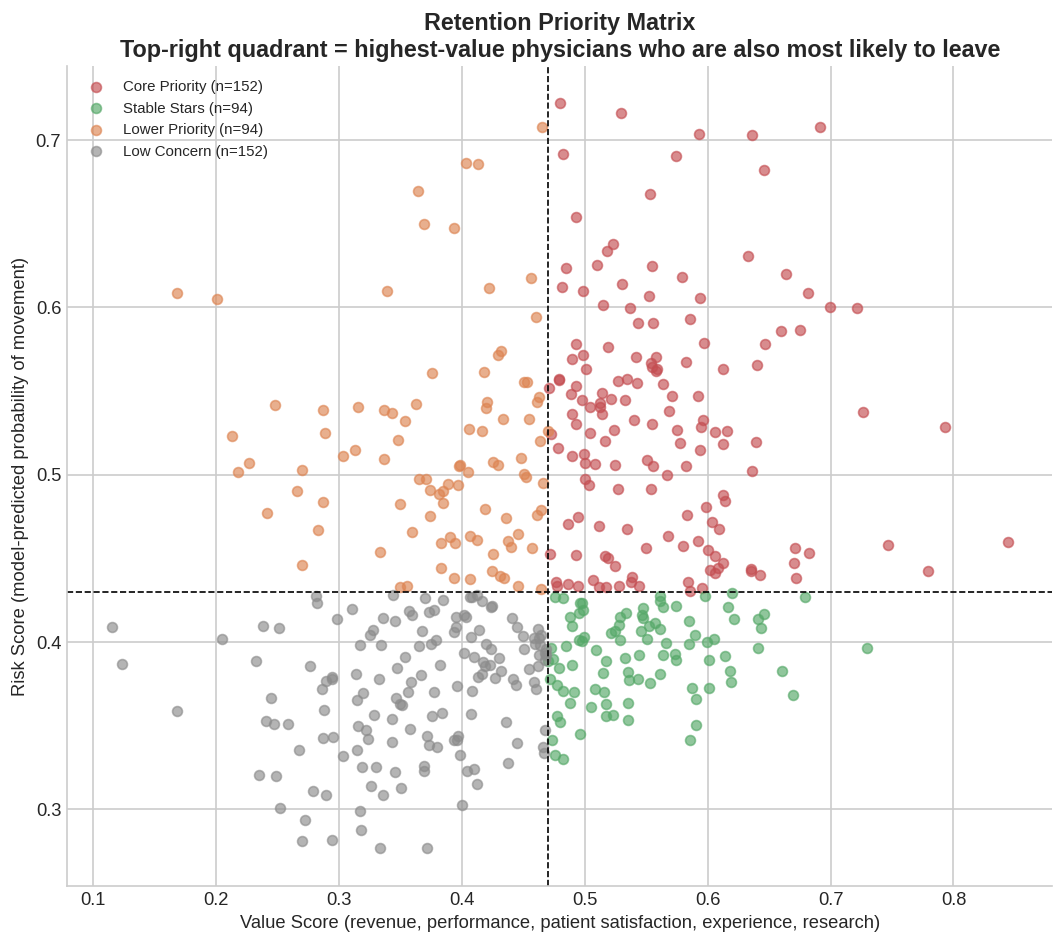

In [27]:
fig, ax = plt.subplots(figsize=(9, 8))
seg_colors = {'Core Priority\n(High Value / High Risk)': '#C44E52', 'Stable Stars\n(High Value / Low Risk)': '#55A868',
              'Lower Priority\n(Low Value / High Risk)': '#DD8452', 'Low Concern\n(Low Value / Low Risk)': '#8C8C8C'}
for seg, color in seg_colors.items():
    sub = master[master['Segment'] == seg]
    ax.scatter(sub['Value_Score'], sub['Risk_Score'], s=35, alpha=0.65, color=color, label=f"{seg.splitlines()[0]} (n={len(sub)})")

ax.axvline(val_med, color='black', linestyle='--', linewidth=1)
ax.axhline(risk_med, color='black', linestyle='--', linewidth=1)
ax.set_xlabel("Value Score (revenue, performance, patient satisfaction, experience, research)")
ax.set_ylabel("Risk Score (model-predicted probability of movement)")
ax.set_title("Retention Priority Matrix\nTop-right quadrant = highest-value physicians who are also most likely to leave", fontweight='bold')
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [28]:
core = master[master['Segment'].str.startswith('Core Priority')]
print(f"Core Priority group: {len(core)} physicians ({len(core)/len(master)*100:.1f}% of the workforce)\n")

compare = pd.DataFrame({
    'Core Priority group': [core['Income_Gap_Pct'].mean(), core['Job_Satisfaction_Score'].mean(),
                             core['Monthly_Revenue_INR'].mean(), core['Current_Tenure_Years'].mean(), core['Outside_Offers_Last_Year'].mean()],
    'Everyone else':       [master.loc[~master.index.isin(core.index), 'Income_Gap_Pct'].mean(),
                             master.loc[~master.index.isin(core.index), 'Job_Satisfaction_Score'].mean(),
                             master.loc[~master.index.isin(core.index), 'Monthly_Revenue_INR'].mean(),
                             master.loc[~master.index.isin(core.index), 'Current_Tenure_Years'].mean(),
                             master.loc[~master.index.isin(core.index), 'Outside_Offers_Last_Year'].mean()],
}, index=['Income Gap %', 'Job Satisfaction (1-5)', 'Monthly Revenue (INR)', 'Tenure (years)', 'Outside Offers/Year'])
display(compare.round(2))

print("\nTop specialties represented in the Core Priority group:")
print(core['Primary_Specialty'].value_counts().head(5))

print("\nSample of the Core Priority list (highest risk first):")
display(core.sort_values('Risk_Score', ascending=False)[['Physician_ID','Primary_Specialty','Current_Department',
        'Current_Hospital','Value_Score','Risk_Score','Job_Satisfaction_Score','Income_Gap_Pct']].head(10).round(2))

Core Priority group: 152 physicians (30.9% of the workforce)



,Core Priority group,Everyone else
Income Gap %,22.51,19.76
Job Satisfaction (1-5),3.20,3.51
Monthly Revenue (INR),5256167.38,4610845.56
Tenure (years),3.32,3.50
Outside Offers/Year,3.34,2.82



Top specialties represented in the Core Priority group:
Primary_Specialty
Neurology           20
Radiology           18
Oncology            18
Pulmonology         16
Gastroenterology    15
Name: count, dtype: int64

Sample of the Core Priority list (highest risk first):


,Physician_ID,Primary_Specialty,Current_Department,Current_Hospital,Value_Score,Risk_Score,Job_Satisfaction_Score,Income_Gap_Pct
423,PHY-0428,Nephrology,Nephrology,Medistar Specialty - Delhi,0.48,0.72,1.71,51.16
101,PHY-0106,Gastroenterology,Gastroenterology,Medistar Specialty - Hyderabad,0.53,0.72,1.80,27.10
143,PHY-0148,Pulmonology,Pulmonology,CarePlus Hospital - Kolkata,0.69,0.71,1.00,27.70
293,PHY-0298,General Medicine,General Medicine,Medistar Specialty - Hyderabad,0.59,0.70,2.13,14.92
246,PHY-0251,Orthopedics,Orthopedics,CarePlus Hospital - Jaipur,0.64,0.70,2.12,26.79
21,PHY-0022,Neurology,Neurology,CarePlus Hospital - Jaipur,0.48,0.69,1.80,22.11
20,PHY-0021,Pediatrics,Pediatrics,Medistar Specialty - Chennai,0.57,0.69,2.21,29.83
95,PHY-0100,Neurology,Neurology,Medistar Specialty - Kolkata,0.65,0.68,1.68,17.45
372,PHY-0377,Neurology,Neurology,Medistar Specialty - Kolkata,0.55,0.67,1.22,16.13
407,PHY-0412,Radiology,Radiology,CarePlus Hospital - Ahmedabad,0.49,0.65,2.60,22.99


### Verdict on Question 2

**152 physicians (31% of the workforce)** fall into the Core Priority quadrant — high value *and* high risk. They generate meaningfully more monthly revenue than everyone else, but carry a *bigger* income gap and *lower* job satisfaction than average. In plain terms: **the organization's most valuable physicians are also its most under-served ones**, concentrated in Neurology, Radiology, and Oncology. This is the list that should drive retention budget and manager attention — not the "At Risk" flag alone, which mixes in a lot of lower-value physicians whose departure would matter far less to the organization.

## 8. Question 3 — How to Increase Physician Loyalty

Recommendations below are drawn directly from the Question 4 findings — no factor is recommended here that wasn't shown to matter above.

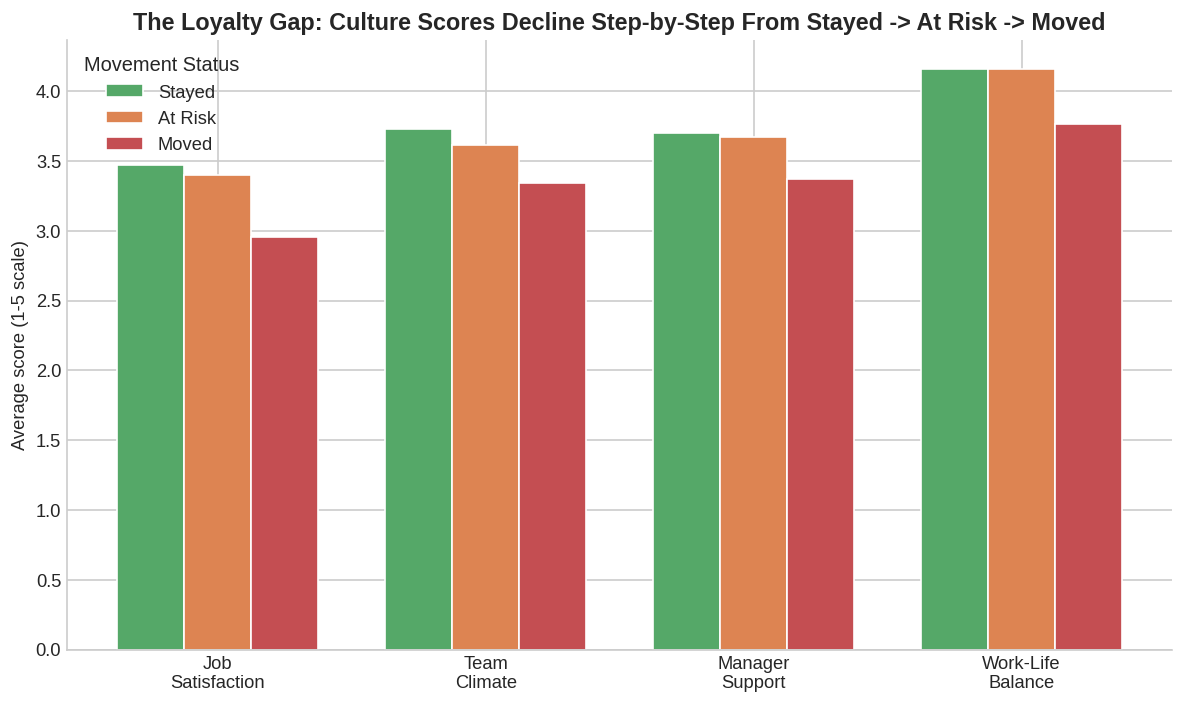

Income gap by status:
Movement_Status_Clean
Stayed     20.2
At Risk    22.1
Moved      19.6
Name: Income_Gap_Pct, dtype: float64


In [29]:
driver_cols = ['Job_Satisfaction_Score','Team_Climate_Score','Manager_Support_Score','Work_Life_Balance_Score']
driver_by_status = master.groupby('Movement_Status_Clean', observed=True)[driver_cols].mean().reindex(['Stayed','At Risk','Moved'])

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(driver_cols))
width = 0.25
colors = ['#55A868', '#DD8452', '#C44E52']
for i, status in enumerate(['Stayed', 'At Risk', 'Moved']):
    ax.bar(x + i*width, driver_by_status.loc[status].values, width, label=status, color=colors[i])
ax.set_xticks(x + width)
ax.set_xticklabels(['Job\nSatisfaction', 'Team\nClimate', 'Manager\nSupport', 'Work-Life\nBalance'])
ax.set_ylabel("Average score (1-5 scale)")
ax.set_title("The Loyalty Gap: Culture Scores Decline Step-by-Step From Stayed -> At Risk -> Moved", fontweight='bold')
ax.legend(title='Movement Status')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print("Income gap by status:")
print(master.groupby('Movement_Status_Clean', observed=True)['Income_Gap_Pct'].mean().reindex(['Stayed','At Risk','Moved']).round(1))

### Recommendations

**1. Fix team climate and manager support first — they're the strongest levers found in Section 6.**
Team Climate is the single strongest predictor in the model, and it's not a compensation problem — it's a day-to-day management and peer-relationship problem. Concretely: structured manager check-ins for the 3-6 year tenure band (where risk peaks), peer-support programs in Pulmonology and Cardiology (the highest-risk specialties), and 360° feedback for department heads whose teams show below-median Team Climate scores.

**2. Close the income gap for the Core Priority group specifically — not across the board.**
Income Gap is the one financial factor both models agreed on. A blanket raise is expensive and untargeted; a compensation review focused on the 152 Core Priority physicians identified in Question 2 (who already show an *above-average* pay gap despite being top revenue generators) is the efficient version of the same fix.

**3. Treat outside offers as an early-warning system, not a surprise.**
Physicians who report outside offers are measurably more at-risk. A lightweight "competitive offer" disclosure/response process — even an informal one where managers check in when they learn of one — turns a lagging indicator into a leading one.

**4. Watch the 3-6 year tenure window and Pulmonology/Cardiology specifically.**
These aren't where the average intervention should be uniform; risk is concentrated, so retention spend should be too.

**5. Don't over-invest in structural changes (contract type, specialty reassignment).**
Section 6 showed these don't move the needle individually — resources are better spent on the culture and compensation levers above.

## 9. Executive Summary

| # | Question | Answer |
|---|---|---|
| 1 | Is physician movement over 50%? | **No.** Only 6.9% moved in 12 months; the broadest "vulnerable" reading (At Risk + Moved) is 31.9%. The 50% concern is not supported by the data, but a real, concentrated problem exists. |
| 2 | Who should be the retention priority? | **152 physicians (31%)** — the "Core Priority" segment: above-average value (revenue, performance, patient satisfaction) combined with above-average departure risk. Concentrated in Neurology, Radiology, and Oncology. |
| 3 | How to increase loyalty? | Fix **team climate and manager support** first (strongest levers); close the **income gap** for the Core Priority group specifically; treat **outside offers** as an early-warning signal; focus effort on the **3-6 year tenure window** and **Pulmonology/Cardiology**. |
| 4 | What drives movement? | **Team Climate, Job Satisfaction, Outside Offers, Income Gap**, and secondarily workload/engagement measures. Specialty, contract type, and tenure alone do *not* predict movement individually — this is a culture-and-compensation problem, not a structural one. |

**One important caveat that applies to all four answers:** the predictive model's accuracy is modest (ROC-AUC ~0.55-0.59). These findings are reliable as *directional, population-level* guidance for where to focus retention effort — they should not be used to flag or act on individual physicians as "flight risks" without corroborating, human judgment.

## 10. Data Quality Decisions, Assumptions & Limitations

**Exclusions:** 8 of 500 physicians (1.6%) were excluded from the merged analytical dataset — 4 due to unresolvable duplicate `Physician_ID` values across sheets, 1 due to a missing ID, plus the resulting gap between the 500-row source sheets and the 492-row inner-joined master table. This is too small a share to bias the conclusions, but it means "492 physicians," not "500," is the true analytical base throughout.

**Imputation:** wellbeing/performance scores were imputed via KNN (leveraging their mutual correlation); other numeric fields via median; categoricals via mode. All imputation rates were under 5% per column. `Reason_for_Last_Move` missingness was structural (never moved) and encoded as an explicit category rather than imputed.

**Outlier treatment:** impossible values (negative percentages, ratings outside their stated scale, sentinel values like 99,999) were set to missing and imputed rather than clipped to a boundary, to avoid fabricating false precision. Genuine statistical outliers with no domain violation (e.g., long-tenure physicians) were kept as-is.

**Target definition:** "At Risk" throughout this notebook means `Movement_Status_12M` = At Risk *or* Moved (after standardizing the original 7 raw labels down to 3 categories). This was a judgment call made to give the model enough positive cases to learn from (162 of 492, 32.9%) — a narrower definition using only actual departures (35 physicians) would have been too small a sample to model reliably.

**Value Score:** a simple, transparent equal-weighted composite (revenue, performance, patient satisfaction, experience, research output). A real deployment should weight these according to organizational priorities (e.g., a research hospital might weight publications higher; a high-volume clinic might weight patient throughput higher) rather than treating all five as equally important.

**Sample size:** 492 physicians is workable for the univariate tests and segmentation, but modest for a machine-learning model with 45 engineered features — this is the main reason the model's ROC-AUC tops out around 0.59 rather than higher. More data (or a longer observation window for the movement label) would likely sharpen the predictive factors identified in Question 4.

---

## Exam quick-reference

| To do this | Write this |
|---|---|
| Read Excel | `pd.read_excel(path)` |
| Structured first look | `.shape` `.info()` `.describe()` `.isnull().sum()` |
| Correlation heatmap | `sns.heatmap(df.corr(numeric_only=True), annot=True)` |
| Group comparison | `df.groupby('segment')[metric].agg(['mean','count'])` |
| Distribution by group | `sns.boxplot(x='group', y='value', data=df)` |
| Fit and evaluate | `model.fit(X_train, y_train)`, `model.score(X_test, y_test)` |
| Which drivers matter | `pd.Series(model.coef_, index=X.columns).sort_values()` |

### Adapting this in the exam

- Given any case study? Use this skeleton: context → load → inspect → clean → explore → prepare → model → interpret → recommend.
- Short of time? Prioritise: a clean dataset with clear EDA and one honest interpretation beats a rushed model with none.
- Always close with two or three concrete, actionable recommendations tied to what you found.

### Traps that cost marks

- Presenting output without interpretation. Every table and chart needs a sentence saying what it means for the business.
- Reporting only the model that worked. Say what you tried and rejected — it demonstrates judgement.
- Quoting an R² or accuracy without saying whether it's on training or test data.
- Skipping the data-quality section. Examiners look for evidence that you checked before you modelled.
- Ending on a number instead of a recommendation. The question is always 'so what should we do?'.